# Word2Vec: Skip-Gram with Negative Sampling - Implementation with Numpy

This notebook walks through the word2vec pipeline implemented with numpy for this task: data preparation, forward pass, gradient derivation, and SGD update. I use a toy corpus to show each step, then map it to the full implementation.

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

---
## 1. The Idea

Word2vec learns a dense vector for each word such that words appearing in similar contexts end up close together in vector space.

**Skip-gram** does this by training a model to predict the context words surrounding a target word. Given the target noun *"cat"* at position 2 in *"the black cat chased mice"* and a window of size 2, the model tries to predict *"the"* (2 left), *"black"* (1 left), *"chased"* (1 right), and *"mice"* (2 right).

Rather than a full softmax over the entire vocabulary (expensive), I use **negative sampling** (Mikolov et al., 2013): for each positive (target, context) pair I draw $K$ noise words at random and train the model to distinguish the real context from the noise.

> Mikolov, T., Sutskever, I., Chen, K., Corrado, G., & Dean, J. (2013). *Distributed representations of words and phrases and their compositionality.* NeurIPS 2013. https://arxiv.org/abs/1310.4546

---
## 2. Data Preparation

### 2.1 Vocabulary

In [7]:
corpus = "the black cat chased mice the old cat caught mice the small cat hunted mice".split()

raw_counts = Counter(corpus)
vocab_items = sorted(raw_counts.items(), key=lambda x: -x[1])

word2idx = {w: i for i, (w, _) in enumerate(vocab_items)}
idx2word = [w for w, _ in vocab_items]
counts   = np.array([c for _, c in vocab_items], dtype=np.int64)  # int64 avoids overflow when summing counts on large corpora (e.g. text8 has ~17M tokens)

print("Vocabulary:", word2idx)
print("Counts:    ", dict(zip(idx2word, counts)))

Vocabulary: {'the': 0, 'cat': 1, 'mice': 2, 'black': 3, 'chased': 4, 'old': 5, 'caught': 6, 'small': 7, 'hunted': 8}
Counts:     {'the': np.int64(3), 'cat': np.int64(3), 'mice': np.int64(3), 'black': np.int64(1), 'chased': np.int64(1), 'old': np.int64(1), 'caught': np.int64(1), 'small': np.int64(1), 'hunted': np.int64(1)}


### 2.2 Subsampling frequent words

Very frequent words like *"the"* carry little information. Mikolov et al. (2013) keep each token $w$ with probability

$$P(\text{keep} \mid w) = \min\!\left(1,\; \sqrt{\frac{t}{f(w)}} + \frac{t}{f(w)}\right)$$

where $f(w)$ is the word's frequency in the corpus and $t$ is a threshold (typically $10^{-5}$). Rare words are almost always kept; very frequent words are aggressively thinned.

> **Note:** on this toy corpus every word has a high relative frequency, so keep probabilities will be low for all words. Subsampling is designed for large corpora (e.g. text8) where only a few extremely frequent words like *"the"* get thinned — the vast majority of words have low enough frequency that $P(\text{keep}) \approx 1$.

In [8]:
t = 1e-3   # higher threshold for our toy corpus
total = counts.sum()
freq  = counts / total
keep_prob = np.minimum(1.0, np.sqrt(t / freq) + t / freq)

for w, f, p in zip(idx2word, freq, keep_prob):
    print(f"  {w:6s}  freq={f:.3f}  P(keep)={p:.3f}")

  the     freq=0.200  P(keep)=0.076
  cat     freq=0.200  P(keep)=0.076
  mice    freq=0.200  P(keep)=0.076
  black   freq=0.067  P(keep)=0.137
  chased  freq=0.067  P(keep)=0.137
  old     freq=0.067  P(keep)=0.137
  caught  freq=0.067  P(keep)=0.137
  small   freq=0.067  P(keep)=0.137
  hunted  freq=0.067  P(keep)=0.137


### 2.3 Negative sampling distribution

Noise words are drawn from a **smoothed unigram distribution**: raw counts raised to the power 0.75. This increases the share of rare words relative to true unigram frequency.

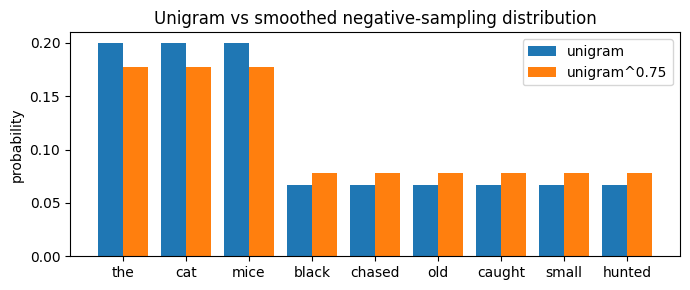

In [9]:
weights = counts.astype(np.float64) ** 0.75
weights /= weights.sum()

x = np.arange(len(idx2word))
fig, ax = plt.subplots(figsize=(7, 3))
ax.bar(x - 0.2, freq,    width=0.4, label='unigram')
ax.bar(x + 0.2, weights, width=0.4, label='unigram^0.75')
ax.set_xticks(x)
ax.set_xticklabels(idx2word)
ax.set_ylabel('probability')
ax.legend()
ax.set_title('Unigram vs smoothed negative-sampling distribution')
plt.tight_layout()
plt.show()

### 2.4 Generating (target, context, negatives) triples

For each token at position $i$ I slide a window of radius `window_size` over the corpus. Every token within the window (excluding $i$ itself) becomes a positive context word. I then sample $K$ noise words for that pair.

In [10]:
def neg_sampler(size):
    return np.random.choice(len(idx2word), size=size, p=weights)

tokens     = np.array([word2idx[w] for w in corpus], dtype=np.int32)
window_size = 2
K           = 3

print(f"{'target':>8}  {'context':>8}  {'negatives'}")
print("-" * 40)
for i in range(len(tokens)):
    lo, hi = max(0, i - window_size), min(len(tokens), i + window_size + 1)
    for j in range(lo, hi):
        if j == i:
            continue
        negs = neg_sampler(K)
        print(f"{idx2word[tokens[i]]:>8}  {idx2word[tokens[j]]:>8}  {[idx2word[n] for n in negs]}")

  target   context  negatives
----------------------------------------
     the     black  ['the', 'old', 'hunted']
     the       cat  ['hunted', 'the', 'the']
   black       the  ['mice', 'the', 'mice']
   black       cat  ['black', 'cat', 'cat']
   black    chased  ['the', 'mice', 'cat']
     cat       the  ['old', 'chased', 'small']
     cat     black  ['black', 'cat', 'the']
     cat    chased  ['cat', 'cat', 'the']
     cat      mice  ['mice', 'caught', 'the']
  chased     black  ['old', 'small', 'the']
  chased       cat  ['the', 'mice', 'cat']
  chased      mice  ['chased', 'old', 'chased']
  chased       the  ['cat', 'cat', 'the']
    mice       cat  ['black', 'chased', 'small']
    mice    chased  ['cat', 'hunted', 'the']
    mice       the  ['small', 'chased', 'mice']
    mice       old  ['black', 'mice', 'mice']
     the    chased  ['the', 'mice', 'the']
     the      mice  ['mice', 'cat', 'hunted']
     the       old  ['the', 'the', 'black']
     the       cat  ['the', 'th

---
## 3. The Model

Two embedding matrices are maintained:

| Name | Shape | Role |
|------|-------|---------|
| **W** | $V \times D$ | Target word embeddings |
| **C** | $V \times D$ | Context and noise word embeddings |

$V$ = vocabulary size, $D$ = embedding dimension.

**W** is initialised uniformly in $[-0.5/D,\; 0.5/D]$ (following the original C code). **C** starts at zero.

In [12]:
V = len(idx2word)
D = 4   # tiny dimension for demonstration
rng  = np.random.default_rng(42)

W = rng.uniform(-0.5 / D, 0.5 / D, (V, D)).astype(np.float32)  # float32: half the memory of float64, faster and sufficient precision for embeddings
C = np.zeros((V, D), dtype=np.float32)

print("W (target embeddings):")
for i, row in enumerate(W):
    print(f"  {idx2word[i]:6s} {np.round(row, 3)}")

W (target embeddings):
  the    [ 0.068 -0.015  0.09   0.049]
  cat    [-0.101  0.119  0.065  0.072]
  mice   [-0.093 -0.012 -0.032  0.107]
  black  [ 0.036  0.081 -0.014 -0.068]
  chased [ 0.014 -0.109  0.082  0.033]
  old    [ 0.065 -0.036  0.118  0.098]
  caught [ 0.07  -0.076 -0.008 -0.114]
  small  [-0.086  0.046  0.061  0.117]
  hunted [-0.044 -0.032 -0.008 -0.078]


---
## 4. Forward Pass and Loss

For a single (target $w$, context $c$, noise words $n_1 \ldots n_K$) triple, the loss is:

$$L = \log(1 + e^{-z_\text{pos}}) + \sum_{k=1}^{K} \log(1 + e^{z_{\text{neg},k}})$$

where $z_\text{pos} = c \cdot w$ and $z_{\text{neg},k} = n_k \cdot w$.

Equivalently, using $\log(1 + e^{-x}) = -\log\,\sigma(x)$:

$$L = -\log\,\sigma(z_\text{pos}) - \sum_{k=1}^{K} \log\,\sigma(-z_{\text{neg},k})$$

The model is trained to assign a **high** dot product to the positive pair and a **low** one to each noise pair.

In [14]:
def sigmoid(x):
    z = np.exp(-np.abs(x))
    return np.where(x >= 0, 1.0 / (1.0 + z), z / (1.0 + z))

# One example triple
target_idx  = word2idx["cat"]
context_idx = word2idx["chased"]
neg_indices = neg_sampler(K)

w = W[target_idx]           # [D]
c = C[context_idx]          # [D]
n = C[neg_indices]          # [K, D]

z_pos = np.dot(w, c)        # scalar
z_neg = np.dot(n, w)        # [K]

loss_pos = -np.log(sigmoid(z_pos) + 1e-10)
loss_neg = -np.log(1.0 - sigmoid(z_neg) + 1e-10).sum()
loss     = loss_pos + loss_neg

print(f"z_pos = {z_pos:.4f}   (target · context)")
print(f"z_neg = {np.round(z_neg, 4)}   (target · noise)")
print(f"loss  = {loss:.4f}")

z_pos = 0.0000   (target · context)
z_neg = [0. 0. 0.]   (target · noise)
loss  = 2.7726


At initialisation $\mathbf{C} = 0$, so all dot products are zero — the model starts at chance.

---
## 5. Backward Pass — Gradients

Differentiating $L$ with respect to the dot products:

$$\frac{\partial L}{\partial z_\text{pos}} = \sigma(z_\text{pos}) - 1 \qquad \frac{\partial L}{\partial z_{\text{neg},k}} = \sigma(z_{\text{neg},k})$$

Applying the chain rule to the embeddings:

$$\frac{\partial L}{\partial w} = (\sigma(z_\text{pos}) - 1)\, c + \sum_{k=1}^{K} \sigma(z_{\text{neg},k})\, n_k$$

$$\frac{\partial L}{\partial c} = (\sigma(z_\text{pos}) - 1)\, w$$

$$\frac{\partial L}{\partial n_k} = \sigma(z_{\text{neg},k})\, w$$

So $\sigma(z_\text{pos}) - 1 < 0$ when the model scores the positive pair highly — so the gradient moves $w$ and $c$ **closer**. $\sigma(z_{\text{neg},k}) > 0$ — the gradient moves $w$ and $n_k$ **apart**.

In [17]:
d_pos = sigmoid(z_pos) - 1.0     # scalar
d_neg = sigmoid(z_neg)           # [K]

grad_w = d_pos * c + (d_neg[:, None] * n).sum(axis=0)   # [D]
grad_c = d_pos * w                                      # [D]
grad_n = d_neg[:, None] * w[None, :]                    # [K, D]

print(f"d_pos   = {d_pos:.4f}   (negative -> pushes w and c closer)")
print(f"d_neg   = {np.round(d_neg, 4)}")
print(f"grad_w  = {np.round(grad_w, 4)}")
print(f"grad_c  = {np.round(grad_c, 4)}")

d_pos   = -0.5000   (negative -> pushes w and c closer)
d_neg   = [0.5 0.5 0.5]
grad_w  = [0. 0. 0. 0.]
grad_c  = [ 0.0507 -0.0595 -0.0326 -0.0358]


### Vectorised over a batch

In practice I process a batch of $B$ pairs at once. The gradients remain **per-sample** (not averaged over $B$):

In [18]:
# Build a small batch
targets_list, contexts_list, negatives_list = [], [], []
for i in range(len(tokens)):
    lo, hi = max(0, i - window_size), min(len(tokens), i + window_size + 1)
    for j in range(lo, hi):
        if j != i:
            targets_list.append(int(tokens[i]))
            contexts_list.append(int(tokens[j]))
            negatives_list.append(neg_sampler(K))

targets   = np.array(targets_list,   dtype=np.int32)          # [B]
contexts  = np.array(contexts_list,  dtype=np.int32)          # [B]
negatives = np.stack(negatives_list).astype(np.int32)         # [B, K]

B = len(targets)
print(f"Batch size: {B} pairs")

w = W[targets]                                             # [B, D]
c = C[contexts]                                            # [B, D]
n = C[negatives]                                           # [B, K, D]

z_pos = (w * c).sum(axis=1)                                # [B]
z_neg = (n * w[:, np.newaxis, :]).sum(axis=2)              # [B, K]

d_pos = sigmoid(z_pos) - 1.0                               # [B]
d_neg = sigmoid(z_neg)                                     # [B, K]

grad_w = d_pos[:, None] * c + (d_neg[:, :, None] * n).sum(axis=1)  # [B, D]
grad_c = d_pos[:, None] * w                                        # [B, D]
grad_n = d_neg[:, :, None] * w[:, None, :]                         # [B, K, D]

print(f"grad_w shape: {grad_w.shape}")
print(f"grad_c shape: {grad_c.shape}")
print(f"grad_n shape: {grad_n.shape}")

Batch size: 54 pairs
grad_w shape: (54, 4)
grad_c shape: (54, 4)
grad_n shape: (54, 3, 4)


---
## 6. SGD Update

The parameter update is:

$$W[i] \leftarrow W[i] - \text{lr} \cdot \nabla_{w_i} L$$

Because the same word can appear multiple times as a target in a single batch, plain fancy-indexing (`W[targets] -= lr * grad_w`) would silently overwrite rather than accumulate. `numpy.add.at` performs an **unbuffered scatter-add**, so every sample's gradient is applied independently — equivalent to $B$ consecutive per-sample SGD steps.

In [19]:
# Demonstrate the difference
arr_fancy = np.zeros(3)
arr_addat = np.zeros(3)
idx  = np.array([0, 0, 1])   # index 0 appears twice
vals = np.array([1.0, 2.0, 3.0])

arr_fancy[idx] += vals        # wrong: second update for idx=0 overwrites the first
np.add.at(arr_addat, idx, vals)

print("fancy indexing:", arr_fancy)   # [2. 3. 0.] — first update lost
print("numpy.add.at:  ", arr_addat)   # [3. 3. 0.] — both updates applied

fancy indexing: [2. 3. 0.]
numpy.add.at:   [3. 3. 0.]


In [21]:
lr = 0.025

np.add.at(W, targets,  -lr * grad_w)
np.add.at(C, contexts, -lr * grad_c)

neg_flat    = negatives.reshape(-1)                        # [B*K]
grad_n_flat = grad_n.reshape(-1, D)                        # [B*K, D]
np.add.at(C, neg_flat, -lr * grad_n_flat)

---
## 7. Mini Training Loop

A training loop on the toy corpus with linear learning rate decay.

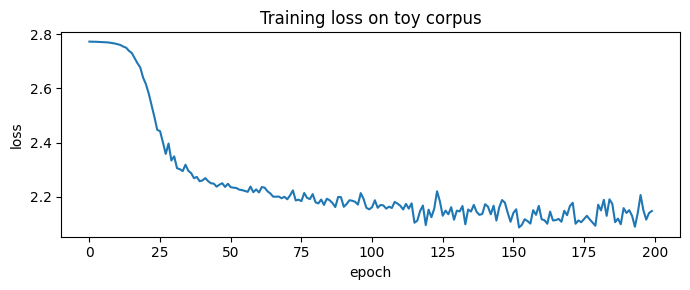

Initial loss: 2.7726  ->  Final loss: 2.1474


In [22]:
np.random.seed(42)
V = len(idx2word)
D = 10
rng  = np.random.default_rng(42)
W = rng.uniform(-0.5 / D, 0.5 / D, (V, D)).astype(np.float32)
C = np.zeros((V, D), dtype=np.float32)

n_epochs   = 200
lr_0       = 0.025
losses     = []

for epoch in range(n_epochs):
    targets_list = []
    contexts_list = []
    negatives_list = []
    for i in range(len(tokens)):
        lo, hi = max(0, i - window_size), min(len(tokens), i + window_size + 1)
        for j in range(lo, hi):
            if j != i:
                targets_list.append(int(tokens[i]))
                contexts_list.append(int(tokens[j]))
                negatives_list.append(neg_sampler(K))

    targets   = np.array(targets_list,  dtype=np.int32)
    contexts  = np.array(contexts_list, dtype=np.int32)
    negatives = np.stack(negatives_list).astype(np.int32)

    w = W[targets]
    c = C[contexts]
    n = C[negatives]

    z_pos = (w * c).sum(axis=1)
    z_neg = (n * w[:, np.newaxis, :]).sum(axis=2)

    sig_pos = sigmoid(z_pos)
    sig_neg = sigmoid(z_neg)

    loss = (-np.log(sig_pos + 1e-10).mean()
            - np.log(1.0 - sig_neg + 1e-10).sum(axis=1).mean())
    losses.append(float(loss))

    d_pos = sig_pos - 1.0
    d_neg = sig_neg

    grad_w = d_pos[:, None] * c + (d_neg[:, :, None] * n).sum(axis=1)
    grad_c = d_pos[:, None] * w
    grad_n = d_neg[:, :, None] * w[:, None, :]

    lr = lr_0 * max(1e-4, 1.0 - epoch / n_epochs)
    np.add.at(W, targets,  -lr * grad_w)
    np.add.at(C, contexts, -lr * grad_c)
    np.add.at(C, negatives.reshape(-1), -lr * grad_n.reshape(-1, D))

plt.figure(figsize=(7, 3))
plt.plot(losses)
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('Training loss on toy corpus')
plt.tight_layout()
plt.show()
print(f"Initial loss: {losses[0]:.4f}  ->  Final loss: {losses[-1]:.4f}")

---
## 8. Evaluation — Nearest Neighbours

Once trained, I retrieve the most similar words using **cosine similarity** on the target embeddings **W**:

$$\text{sim}(u, v) = \frac{u \cdot v}{\|u\|\, \|v\|}$$

In [23]:
def most_similar(word, W, word2idx, idx2word, top_k=3):
    idx    = word2idx[word]
    vec    = W[idx]
    norms  = np.linalg.norm(W, axis=1, keepdims=True) + 1e-10
    normed = W / norms
    scores = normed @ (vec / (np.linalg.norm(vec) + 1e-10))
    scores[idx] = -np.inf
    top    = np.argsort(scores)[::-1][:top_k]
    return [(idx2word[i], float(scores[i])) for i in top]

for probe in idx2word:
    neighbours = most_similar(probe, W, word2idx, idx2word)
    nn_str = ", ".join(f"{w}({s:.2f})" for w, s in neighbours)
    print(f"  {probe:6s} -> {nn_str}")

  the    -> hunted(0.96), chased(0.77), caught(0.75)
  cat    -> chased(0.71), small(0.70), caught(0.65)
  mice   -> black(0.97), small(0.78), caught(0.74)
  black  -> mice(0.97), small(0.86), caught(0.83)
  chased -> caught(0.93), old(0.92), small(0.83)
  old    -> caught(0.98), small(0.92), chased(0.92)
  caught -> old(0.98), chased(0.93), small(0.91)
  small  -> old(0.92), caught(0.91), black(0.86)
  hunted -> the(0.96), caught(0.83), old(0.79)


---
## 9. Full Training on text8

The toy corpus above illustrates every step of the algorithm. The full implementation in this repository applies the same logic to the **text8** corpus (~17 million tokens before subsampling).

To train:

```bash
python train.py
```

After 5 epochs (dim=100, window=2, K=5) the nearest neighbours for probe words are:

```
king     -> vii(0.962), emperor(0.939), viii(0.936), crowned(0.933), constantine(0.928)
paris    -> bologna(0.916), petersburg(0.912), concord(0.908), munich(0.905), syracuse(0.899)
computer -> graphical(0.931), desktop(0.924), design(0.923), hardware(0.920), computers(0.920)
good     -> lot(0.920), things(0.912), everyone(0.911), worry(0.908), give(0.905)
one      -> seven(0.893), six(0.879), eight(0.878), four(0.865), five(0.852)
```

The code in `model.py` and `data.py` is a direct scale-up of what is shown in this notebook.